# Encoding Numerical Data

- Encoding numerical data means scaling or transforming numbers so machine-learning models can learn fairly without being biased by large values or skewness

- Even though data is already “numbers”, raw numbers can confuse models if they are not prepared correctly.
 - Different numbers have different scale
 - Large values dominate small ones
 - Some numbers represent categories, not real quantities


## Types of Numerical Data

1. Continuous Numerical Data
- can be any value: age, salary, temperature
3. Discrete Numerical Data
- countable value
4. Numerical but Categorical
- low, medium, high

## Common Ways to Encode Numerical Data

1. Scaling
- makes data centered around 0
- Normalization (most common): Brings values b/w 0 and 1
3. Transformation (Fix Skewed data)
- Log transform
- Box Cox
- Yeo Johnson
- Makes uneven data more balanced
4. Binning (Discretization)
- converts numbers into ranges.
>
- Why use Discretization
 - handle outliers
 - improve the value spread

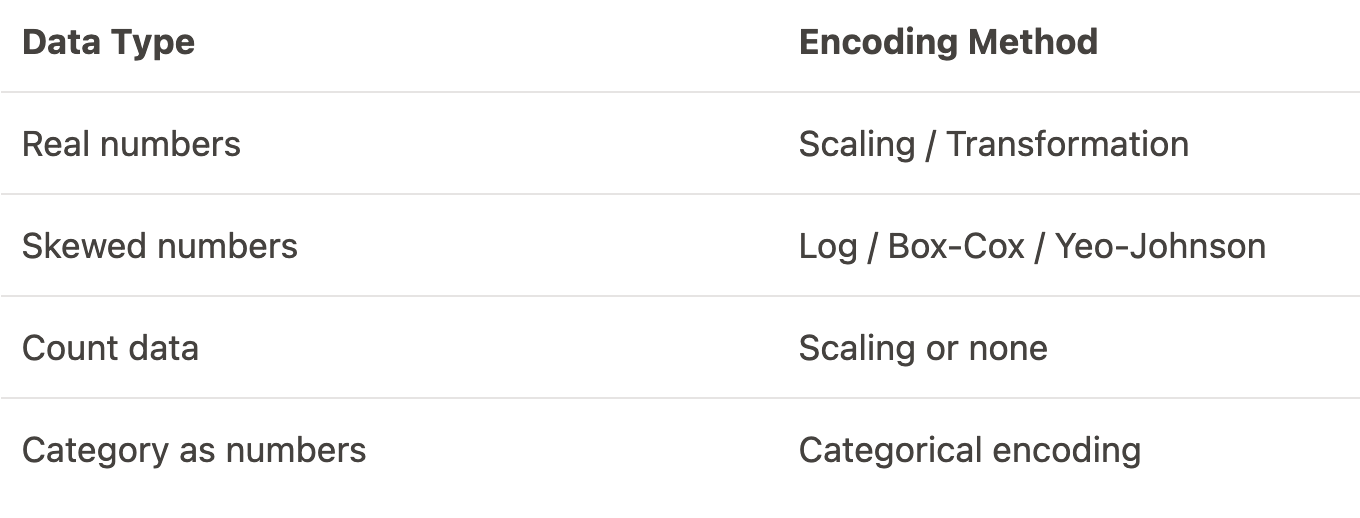  

### Types of Discretization

Binning

1. Unsupervised
- Equal width (uniform)
- Equal frequency
- K means
>
>
2. Supervised
- Decision tree binning
>
>
3. Custom

### 1. Equal Width/Uniform Binning

- If we have data e.g age so first we need to tell how many bins we need e.g 10 bins. So we will apply max-min/total numbers of bins. For example you have 100 mx , 0 is min and 10 bin
- First benefit is outliers handle. Second spread of data not change

### 2. Equal frequency/Quantile Binning

- Equal frequency binning divides data so that each bin contains the same number of observations, even if the value ranges differ
>
- Why do we use Equal Frequency Binning?
- data is Unevenly distributed
- Skewed (many small values, few large ones)

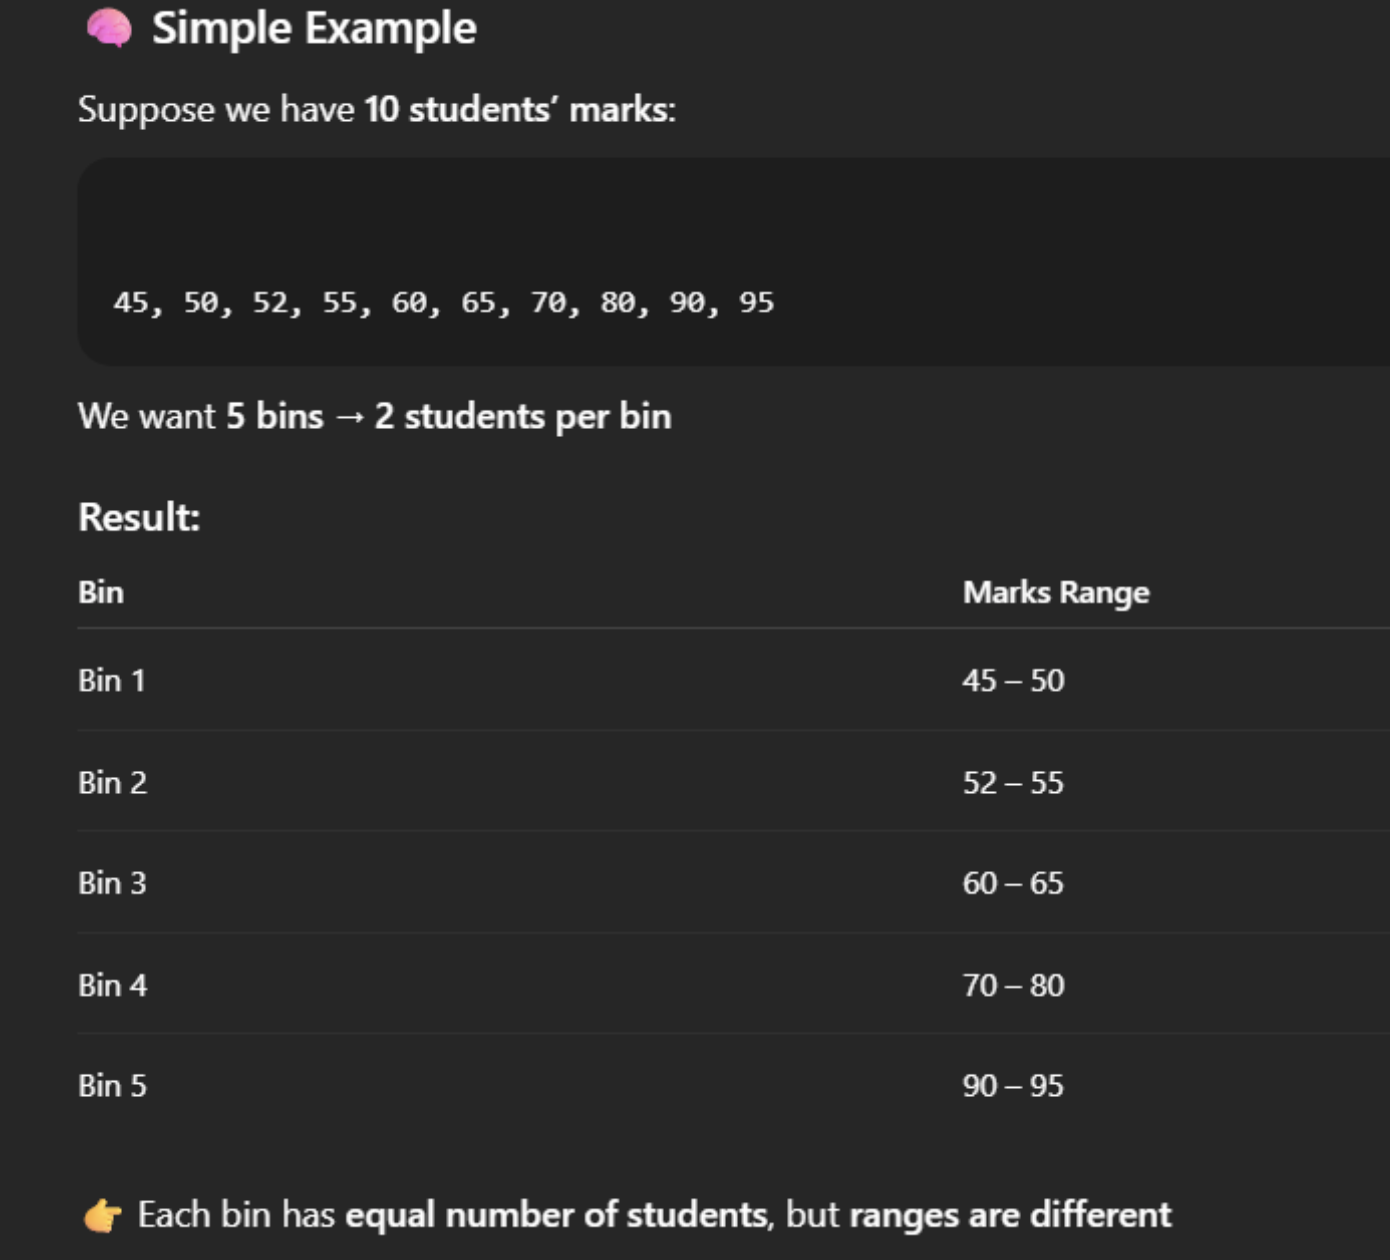

### K Means 

K-Means automatically groups similar values together based on closeness.

Eg:
students marks:
40, 45, 50, 72, 75, 80, 90, 95

Group 1 → low marks
Group 2 → medium marks
Group 3 → high marks

# Code Example

## Without Binning

In [6]:
import pandas as pd
import numpy as np

In [20]:
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer

In [28]:
df = pd.read_csv('../datasets/titanic/train.csv',usecols=['Age','Fare','Survived'])

In [30]:
df.dropna(inplace=True) # We use dropna for dropping all missing values.

In [31]:
df.shape

(714, 3)

In [32]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [33]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

In [34]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [35]:
X_train.head(2)

,Age,Fare
328,31.0,20.5250
73,26.0,14.4542


In [42]:
clf = DecisionTreeClassifier()

In [43]:
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)

In [45]:
accuracy_score(y_test,y_pred)

0.6293706293706294

In [46]:
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

0.6330790297339594

Cross Validation

- How accurate is my Decision Tree model on average?
- Give me one final accuracy number that represents overall performance.

Instead of training once, we Split data into 10 parts (cv = 10)
- Train on 9 parts
- Test on 1 part
- Repeat this 10 times



scoring=“accuracy”
- “Measure performance using accuracy”
- Accuracy = Correct predictions ÷ Total predictions

np.mean(...)
- This calculates the average accuracy

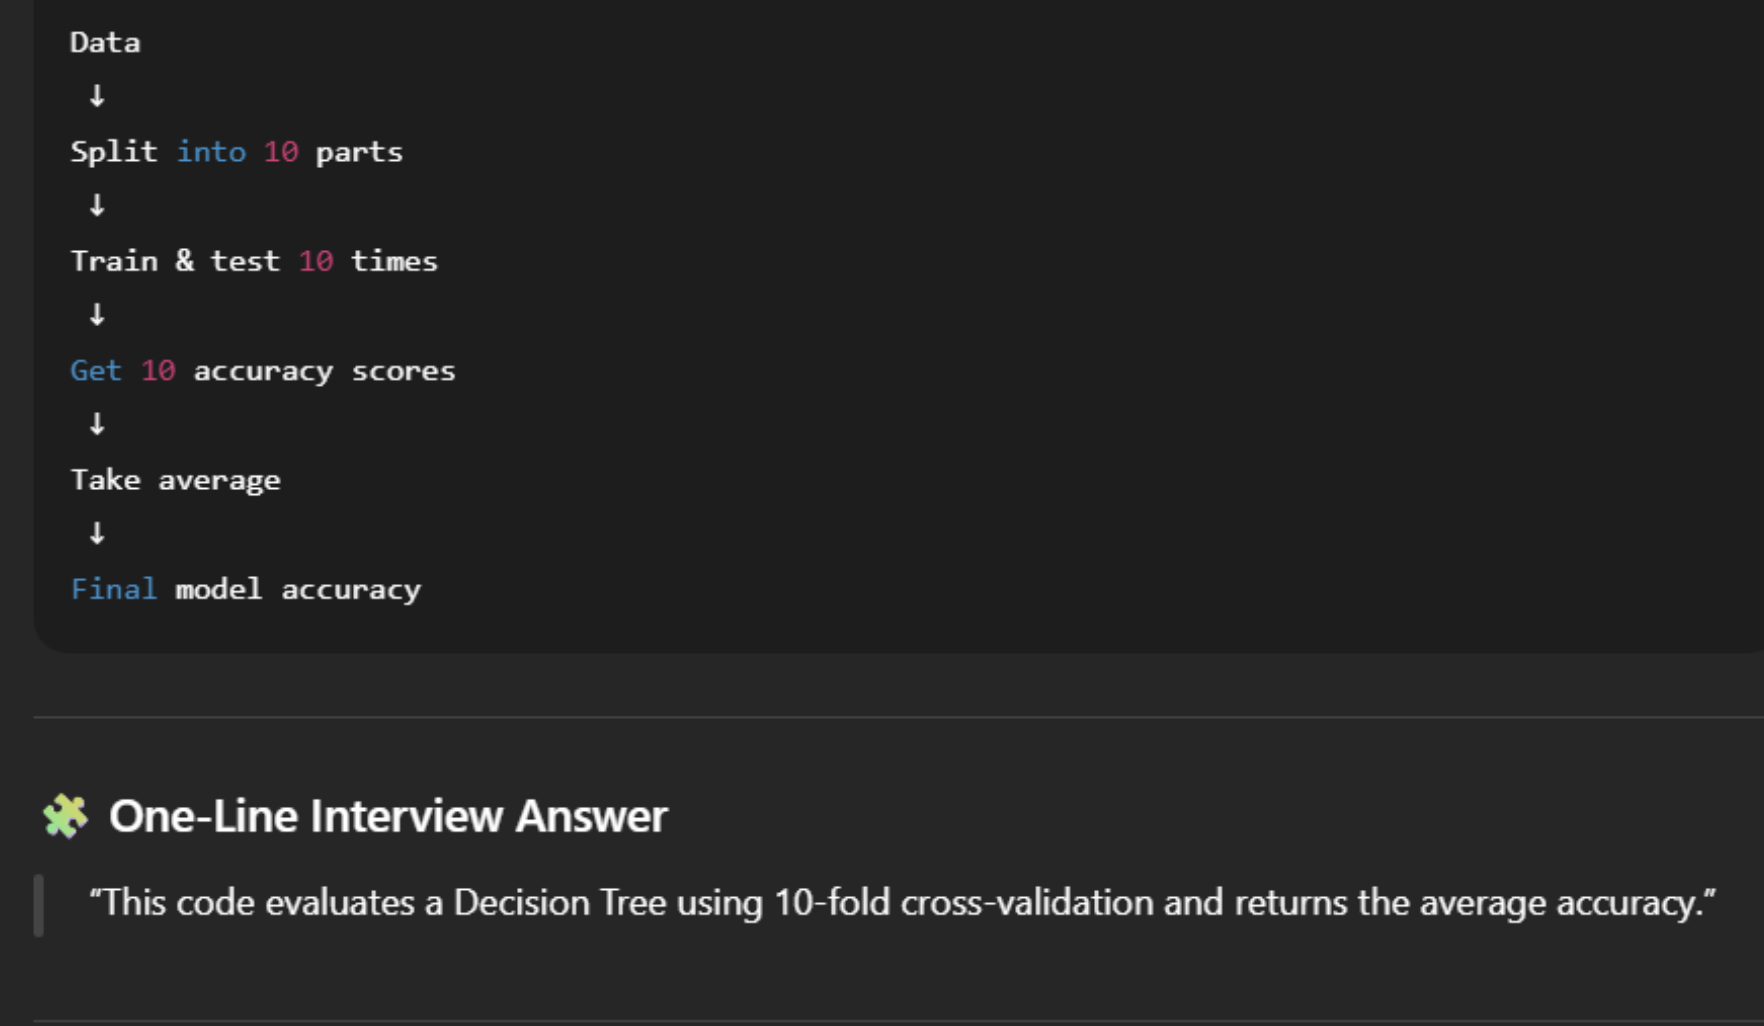


In [47]:
kbin_age = KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='quantile')
kbin_fare = KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='quantile')

In [48]:
trf = ColumnTransformer([
    ('first',kbin_age,[0]),
    ('second',kbin_fare,[1])
])
# Apply age binning to column 0
# Apply fare binning to column 1
# ColumnTransformer helps apply different transformations to different columns

In [50]:
X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)

/Users/mycomputer/.pyenv/versions/3.12.3/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
/Users/mycomputer/.pyenv/versions/3.12.3/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(




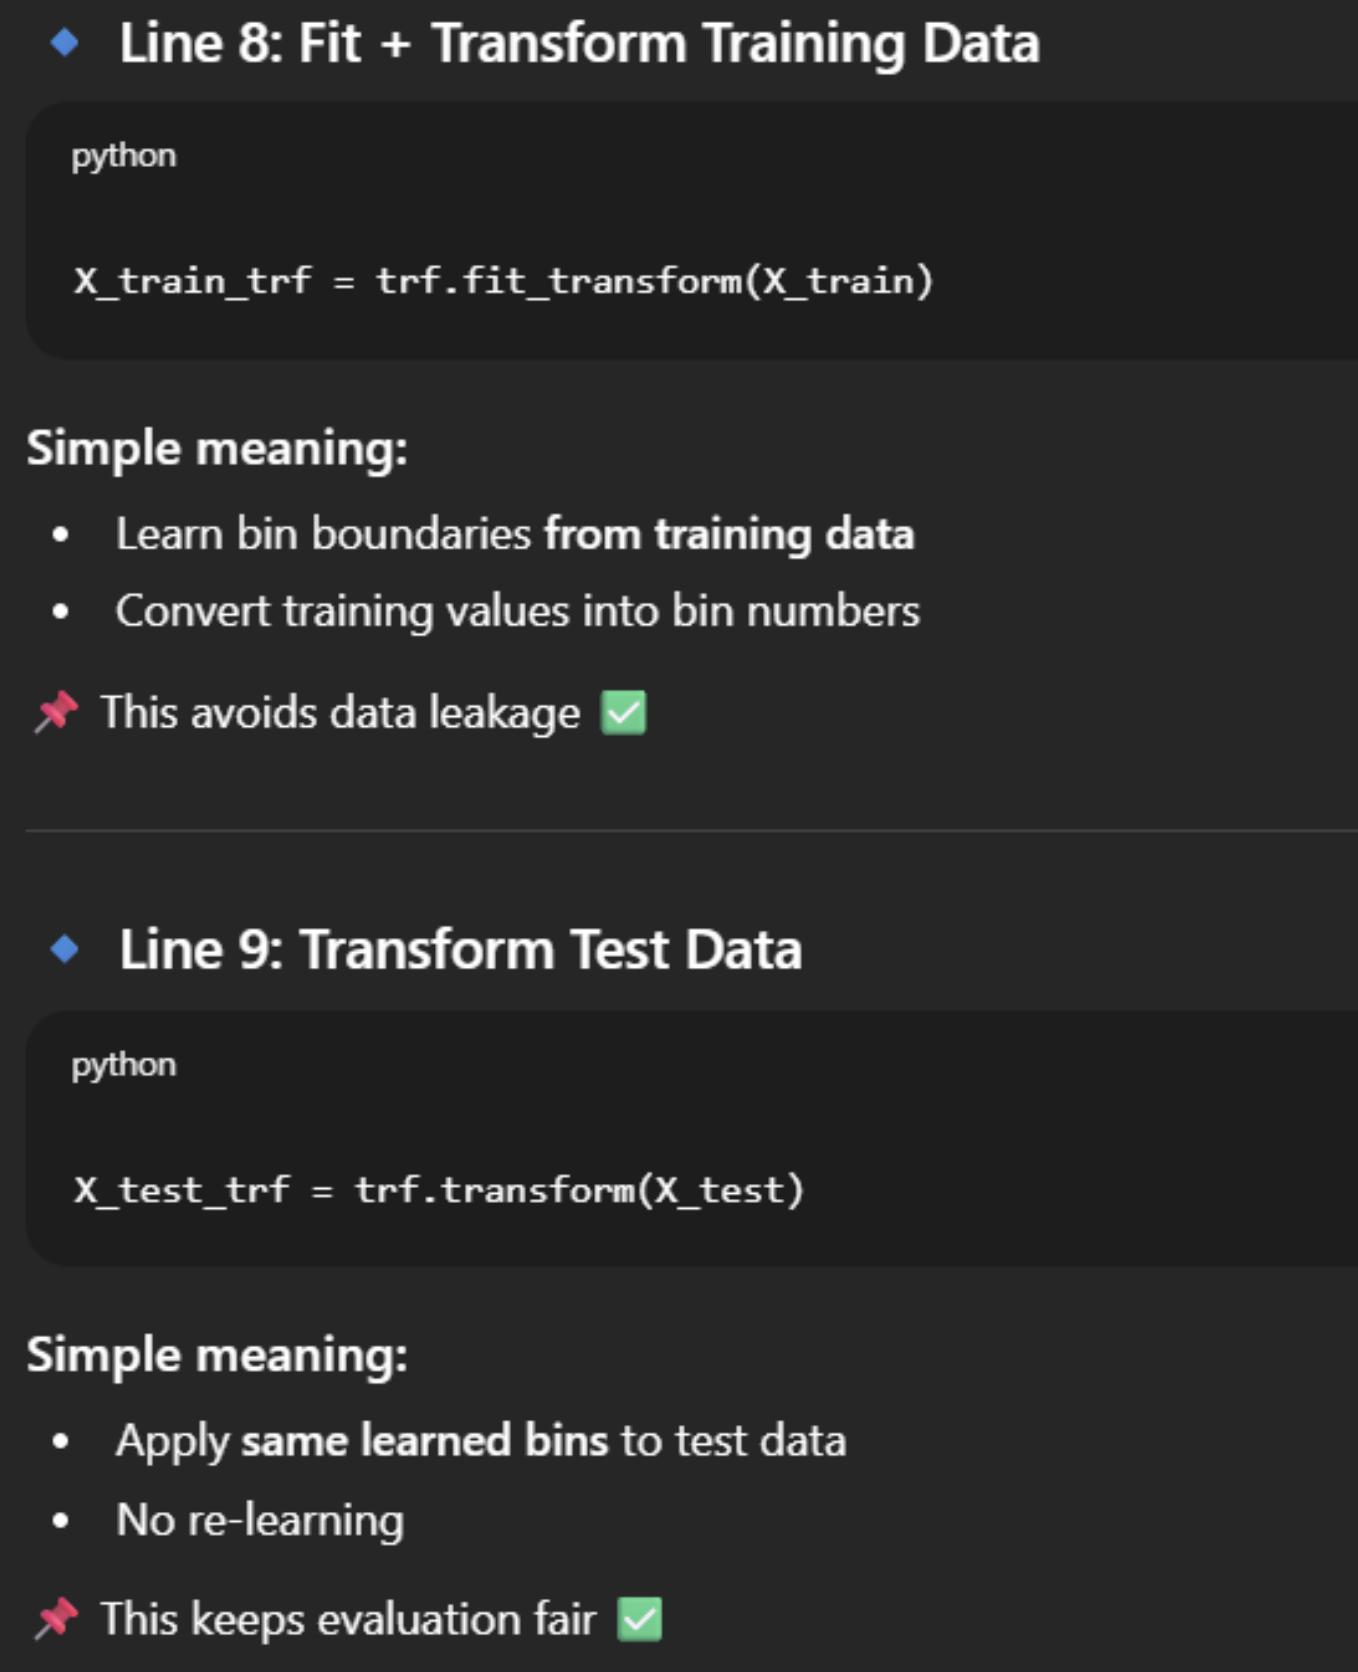


In [51]:
trf.named_transformers_['first'].bin_edges_

array([array([ 0.42,  6.  , 16.  , 19.  , 21.  , 23.  , 25.  , 28.  , 30.  ,
              32.  , 35.  , 38.  , 42.  , 47.  , 54.  , 80.  ])             ],
      dtype=object)

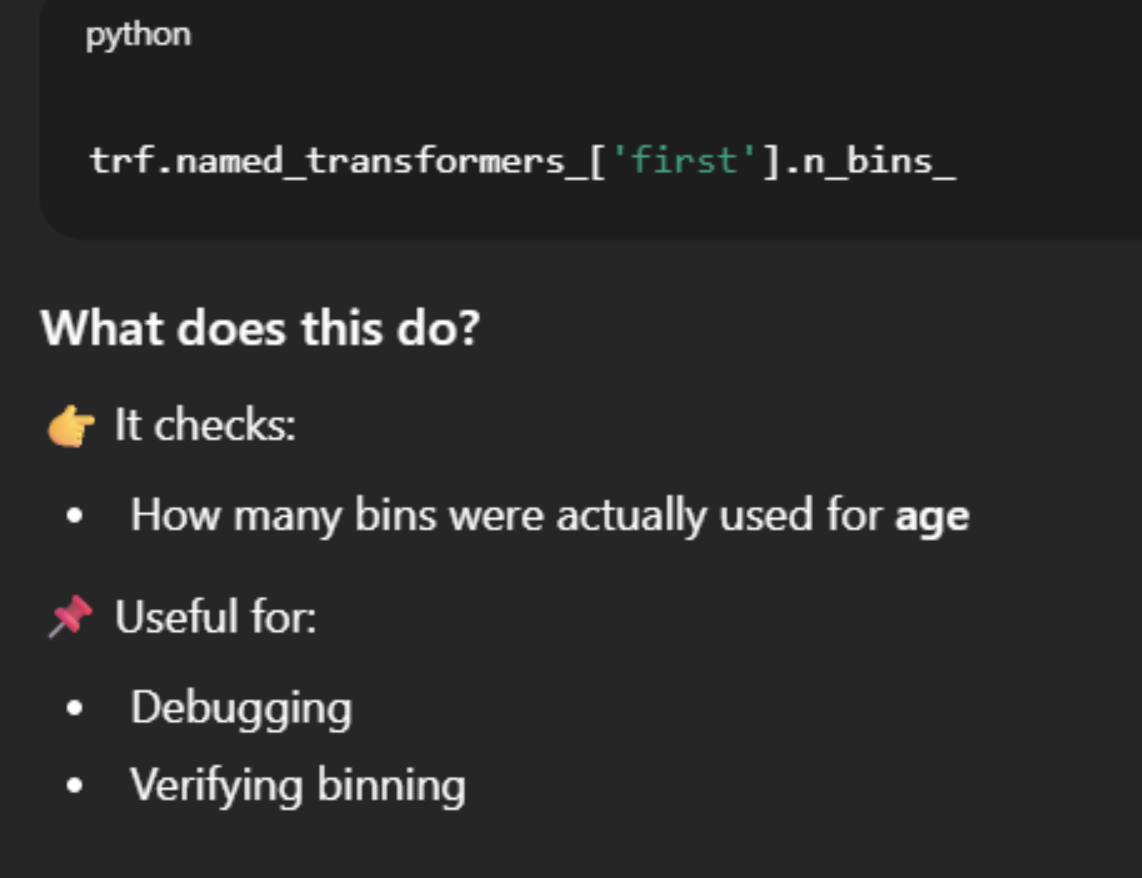


This code is doing quantile binning on two numerical columns (age and fare) using KMeansDiscretizer, and applying it correctly on train & test data using a transformer.


n_bins = 10 :  Divide values into 10 groups

strategy = ‘quantile’ : Each group has equal number of data points

encode = ‘ordinal’ : Output will be numbers like 0, 1, 2, …, 9



In [52]:
output = pd.DataFrame({
    'age':X_train['Age'],
    'age_trf':X_train_trf[:,0],
    'fare':X_train['Fare'],
    'fare_trf':X_train_trf[:,1]
})

In [53]:
output

,age,age_trf,fare,fare_trf
328,31.0,8.0,20.5250,8.0
73,26.0,6.0,14.4542,7.0
253,30.0,8.0,16.1000,7.0
719,33.0,9.0,7.7750,2.0
666,25.0,6.0,13.0000,6.0
...,...,...,...,...
92,46.0,12.0,61.1750,12.0
134,25.0,6.0,13.0000,6.0
337,41.0,11.0,134.5000,14.0
548,33.0,9.0,20.5250,8.0


In [56]:
output['age_labels'] = pd.cut(x=X_train['Age'],
                              bins=trf.named_transformers_['first'].bin_edges_[0].tolist())
output['fare_labels'] = pd.cut(x=X_train['Fare'],
                                    bins=trf.named_transformers_['second'].bin_edges_[0].tolist())

named_transformers_[‘first’] → the transformer for age

bin_edges_ → the cut points used to create bins


Creates a new DataFrame called output

Combines:

- Original Age
- Binned Age
- Original Fare
- Binned Fare


This code extracts bin boundaries, applies them to label original values, and builds a DataFrame to compare raw and binned features.

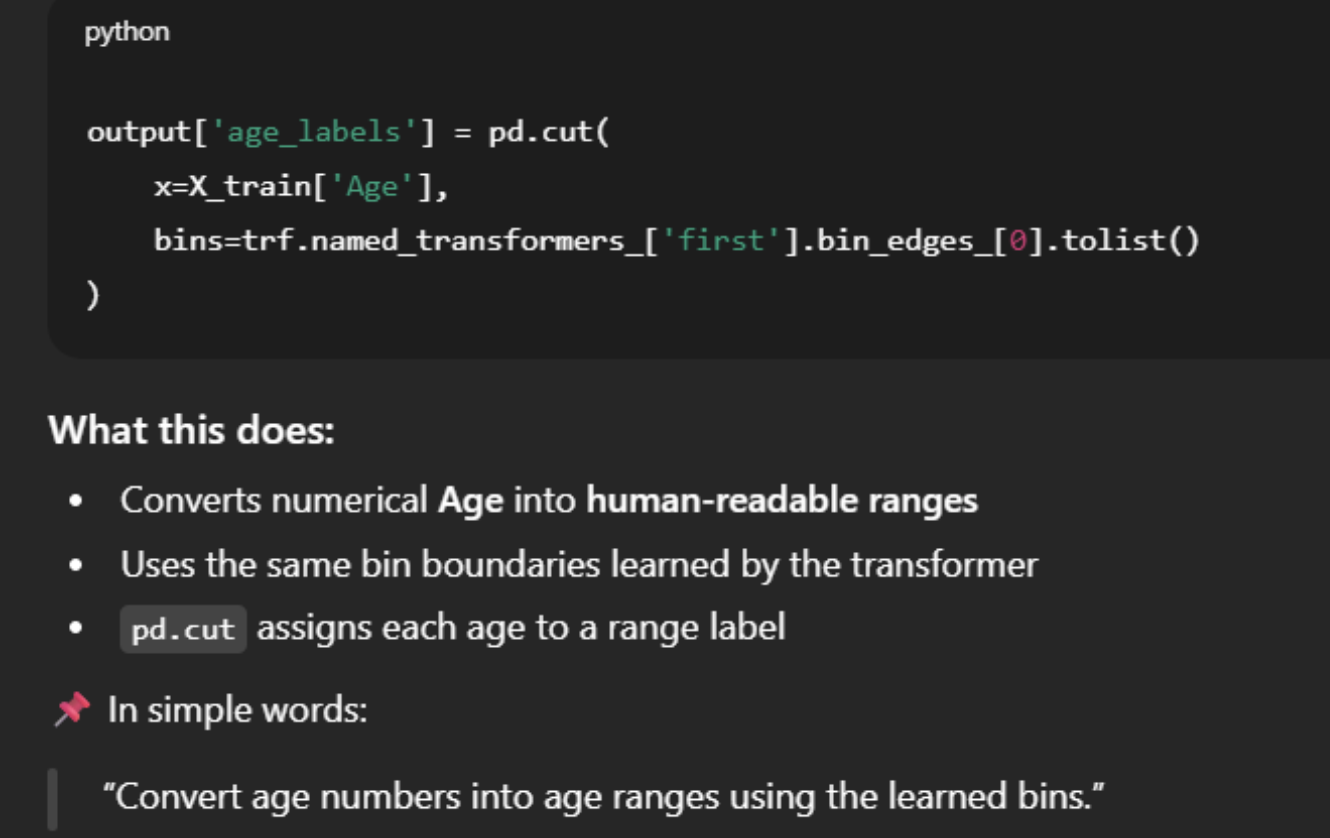


In [57]:
output.sample(5)

,age,age_trf,fare,fare_trf,age_labels,fare_labels
510,29.0,7.0,7.75,1.0,"(28.0, 30.0]","(7.25, 7.775]"
357,38.0,11.0,13.00,6.0,"(35.0, 38.0]","(10.5, 13.0]"
587,60.0,14.0,79.20,13.0,"(54.0, 80.0]","(76.292, 108.9]"
344,36.0,10.0,13.00,6.0,"(35.0, 38.0]","(10.5, 13.0]"
696,44.0,12.0,8.05,3.0,"(42.0, 47.0]","(7.896, 8.158]"


In [58]:
clf = DecisionTreeClassifier()
clf.fit(X_train_trf,y_train)
y_pred2 = clf.predict(X_test_trf)

In [59]:
accuracy_score(y_test,y_pred2)

0.6363636363636364

In [60]:
X_trf = trf.fit_transform(X)
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

/Users/mycomputer/.pyenv/versions/3.12.3/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
/Users/mycomputer/.pyenv/versions/3.12.3/lib/python3.12/site-packages/sklearn/preprocessing/_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


0.6247261345852895

In [61]:
def discretize(bins,strategy):
    kbin_age = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    kbin_fare = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    
    trf = ColumnTransformer([
        ('first',kbin_age,[0]),
        ('second',kbin_fare,[1])
    ])
    
    X_trf = trf.fit_transform(X)
    print(np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy')))
    
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Age'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,0],color='red')
    plt.title("After")

    plt.show()
    
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Fare'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,1],color='red')
    plt.title("Fare")

    plt.show()
    

0.6317292644757433


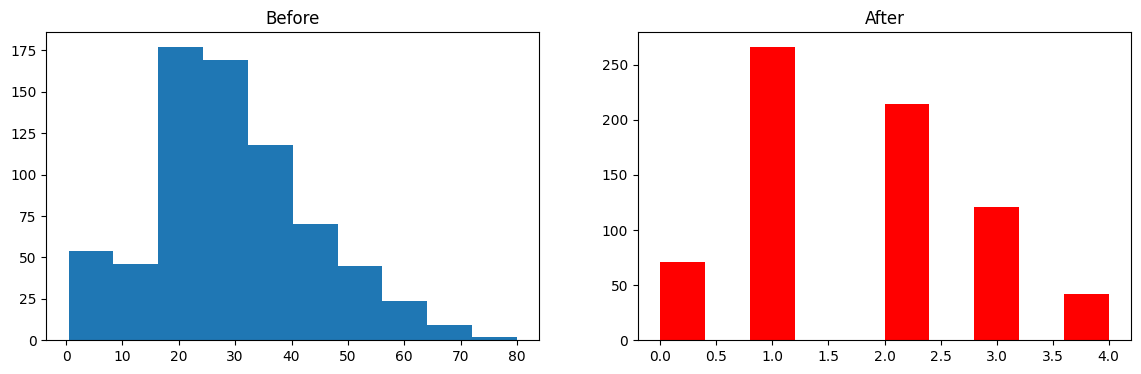

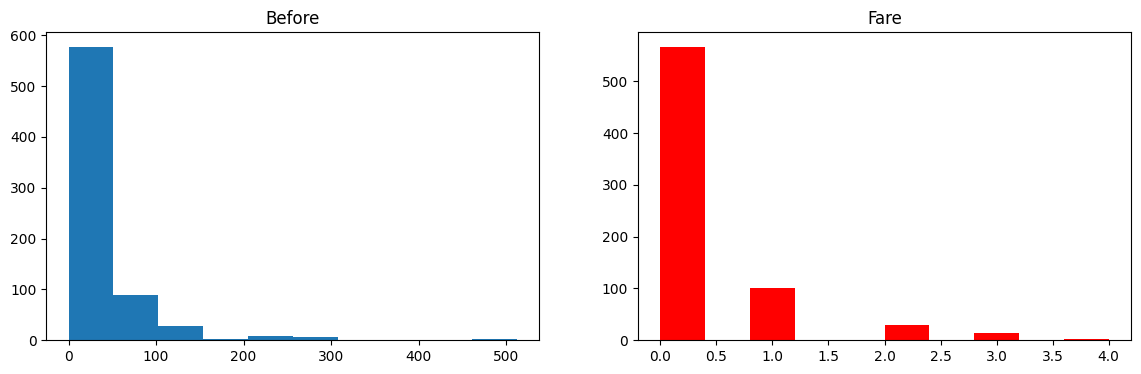

In [62]:
discretize(5,'kmeans')